<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/_energy_track/E2_Multivariate_Demand_RNN.ipynb)

# Multivariate RNN: Electricity Demand
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Drop the lag columns. Hand the RNN the raw multivariate sequence as a **3-D tensor** `(samples, look-back, features)` - weather and clock on the left, **demand as the last column** - and let it decide what to remember. SimpleRNN first, then the one-word LSTM swap, then a stacked model with `return_sequences=True`, always scored against the naive baselines.

*Energy-track version of the occupancy RNN notebook.*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 9B — Multivariate RNN Pt 1: split_sequences, column order, the 3-D tensor
- Multivariate differs from univariate only in prep: covariates on the left, target as the LAST column - and the target's own history stays in X. split_sequences takes y from the right.
- Look-back 24 -> (8736, 24, 8) train tensor. Walk the shape: samples, look-back, features. Inherit n_steps/n_features from the shape.
- SimpleRNN(30) with a LINEAR head (regression, MW) - params (8+30)*30+30 = 1,170 plus 31 for the head.
- Scale on train only; a separate scaler for the target so you can inverse_transform back to megawatts.
- Read the MAE against persistence (129) and seasonal naive (227): SimpleRNN ~48 MW, because the target's own past is in the window. That's the whole point of the column-order slide.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## Baselines

In [3]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only":                       mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yday)": mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (last hour)":         mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only                          563.3
seasonal naive (same hour yday)    227.1
persistence (last hour)            129.0
Name: test MAE (MW), dtype: float64

## Prep: `split_sequences` and the 3-D tensor

Scale on train only. `split_sequences` takes the inputs from **every** column - demand's own past included - and the target from the last column at the **next** step.

<!-- WINDOW-FN -->
## The window-making function: `split_sequences`

Target in the **last column**, then:

- **`n_steps`** is the **look-back**: X is the last `n_steps` rows of **every column, the target included**. Yesterday's demand is the most useful input there is.
- y is the target **one step** after the window ends.

Result: X is `(samples, n_steps, n_features)`.


In [4]:
def split_sequences(seqs, n_steps):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps, -1])   # inputs = EVERY column (demand's own past included); target = last col, NEXT step
    return np.array(X), np.array(y)

n_steps = 24
sc   = MinMaxScaler().fit(train)               # fit on TRAIN only
sc_y = MinMaxScaler().fit(train[["Demand"]])   # a separate scaler for the target so we can get MW back
tr_s, te_s = sc.transform(train), sc.transform(test)
X_train, y_train = split_sequences(tr_s, n_steps)
X_test,  y_test  = split_sequences(te_s, n_steps)
n_features = X_train.shape[2]
y_true = sc_y.inverse_transform(y_test.reshape(-1, 1)).ravel()   # test target in MW
print("train tensor:", X_train.shape, "-> (samples, look-back, features) | test:", X_test.shape)

train tensor: (8736, 24, 8) -> (samples, look-back, features) | test: (8736, 24, 8)


## What exactly is one sample?

One sample is a **24-hour block of every column**, and the model predicts **demand in the next hour**.

Two details that catch people:

1. **Demand's own past is an input here.** `split_sequences` keeps every column, demand included, so the model can
   lean on yesterday's shape. The occupancy notebook does the opposite and drops its target column.
2. **The target is the step after the window** - `seqs[i+n_steps, -1]` - so this is a one-hour-ahead forecast, not
   a nowcast.

*The clock columns (`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`) are explained in
**`Motivating_ConvLSTM_and_Bidirectional`**, which is worth watching before this notebook.*

In [5]:
cols = list(train.columns)
print("X shape:", X_train.shape, "= (samples, hours, features)   y shape:", y_train.shape)
print()
print(f"one sample - X_train[0] - is a {n_steps} x {len(cols)} block. Last 6 hours of it:")
display(pd.DataFrame(X_train[0][-6:], columns=cols,
                     index=[f"t-{i}" for i in range(5, -1, -1)]).round(3))
print(f"its label y_train[0] = {y_train[0]:.3f} (scaled) = "
      f"{sc_y.inverse_transform([[y_train[0]]])[0][0]:,.0f} MW  <- demand in the NEXT hour")

X shape: (8736, 24, 8) = (samples, hours, features)   y shape: (8736,)

one sample - X_train[0] - is a 24 x 8 block. Last 6 hours of it:


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
t-5,0.062,0.0,0.537,0.000,0.500,0.5,1.0,0.629
t-4,0.040,0.0,0.569,0.017,0.629,0.5,1.0,0.618
t-3,0.019,0.0,0.652,0.067,0.750,0.5,1.0,0.589
t-2,0.040,0.0,0.569,0.146,0.854,0.5,1.0,0.541
t-1,0.000,0.0,0.713,0.250,0.933,0.5,1.0,0.474
t-0,0.000,0.0,0.752,0.371,0.983,0.5,1.0,0.416


its label y_train[0] = 0.380 (scaled) = 3,734 MW  <- demand in the NEXT hour


## One helper to score every model

Every model below gets the same treatment so they are comparable: **test MAE in megawatts**, printed next to the
two baselines it has to beat, then two pictures - actual against predicted, and one week of the test year so you
can see *where* it goes wrong rather than just how much.

In [6]:
scores = {}

def show_results(name, pred, truth=None):
    """Score a demand model in MW, then show it two ways: actual vs predicted, and one test week."""
    truth = y_true if truth is None else truth
    mae = mean_absolute_error(truth, pred)
    scores[name] = round(mae, 1)
    print(f"{name}: test MAE = {mae:.1f} MW"
          f"   (persistence {baselines.iloc[2]:.1f}, seasonal naive {baselines.iloc[1]:.1f})")

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1, 2]})
    ax[0].scatter(truth, pred, s=3, alpha=0.3)
    lo, hi = min(np.min(truth), np.min(pred)), max(np.max(truth), np.max(pred))
    ax[0].plot([lo, hi], [lo, hi], "r--")
    ax[0].set_xlabel("actual (MW)"); ax[0].set_ylabel("predicted (MW)"); ax[0].set_title(name)
    i0 = 24 * 7 * 28                      # one week, deep enough into the test year to be interesting
    ax[1].plot(truth[i0:i0 + 24*7], label="actual", lw=1.4)
    ax[1].plot(pred[i0:i0 + 24*7], label=name, lw=1.1)
    ax[1].set_ylabel("MW"); ax[1].set_xlabel("hour of one test week"); ax[1].legend()
    plt.tight_layout(); plt.show()

## SimpleRNN with a linear head

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,201 (4.69 KB)

 Trainable params: 1,201 (4.69 KB)

 Non-trainable params: 0 (0.00 B)

...

 93/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7137e-04 - mae: 0.0100

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7261e-04 - mae: 0.0101

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7261e-04 - mae: 0.0101 - val_loss: 1.9822e-04 - val_mae: 0.0108


Epoch 50: early stopping


Restoring model weights from the end of the best epoch: 42.


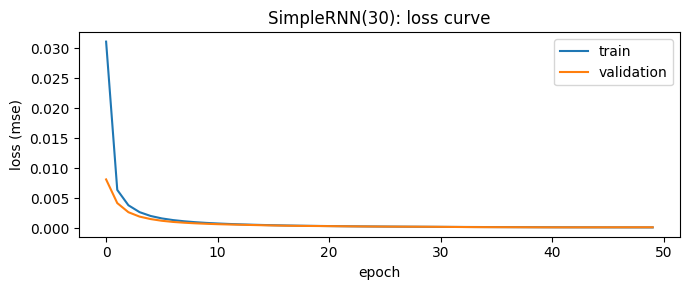

stopped after 50 epochs; best validation loss 0.00019


In [7]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

rnn = Sequential()
rnn.add(Input(shape=(n_steps, n_features)))
rnn.add(SimpleRNN(30))
rnn.add(Dense(1))   # linear output: we predict megawatts
rnn.compile(optimizer="adam", loss="mse", metrics=["mae"])
rnn.summary()
hist = rnn.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist.history["loss"], label="train")
if "val_loss" in hist.history:
    plt.plot(hist.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("SimpleRNN(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(hist.history["loss"]), "epochs;",
      "best validation loss", round(min(hist.history["val_loss"]), 5))

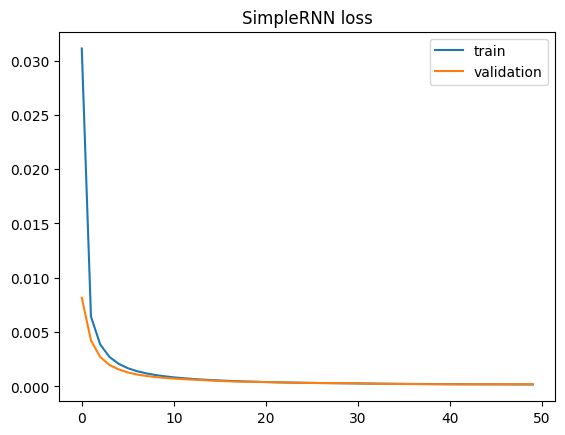

SimpleRNN(30): test MAE = 47.9 MW   (persistence 129.0, seasonal naive 227.1)


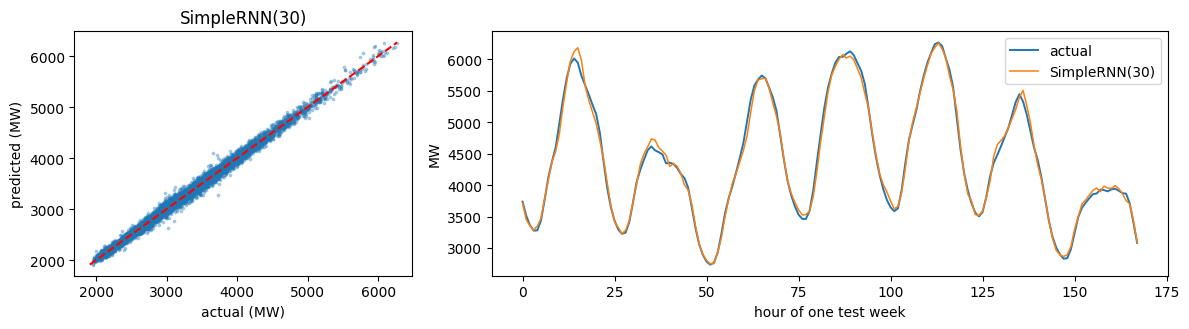

In [8]:
plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="validation"); plt.legend(); plt.title("SimpleRNN loss"); plt.show()
pred_rnn = sc_y.inverse_transform(rnn.predict(X_test, verbose=0)).ravel()
show_results("SimpleRNN(30)", pred_rnn)

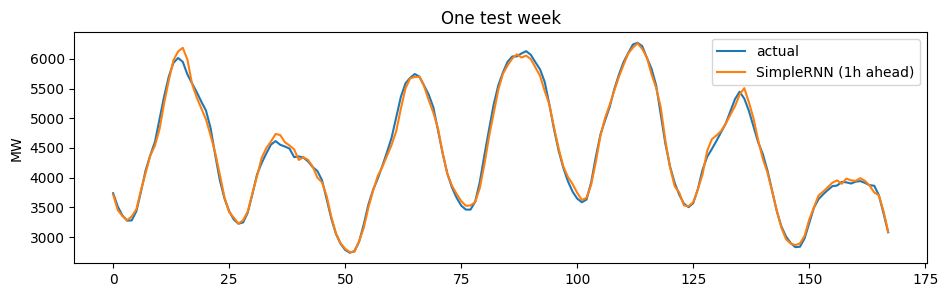

SimpleRNN(30): test MAE = 47.9 MW   (persistence 129.0, seasonal naive 227.1)


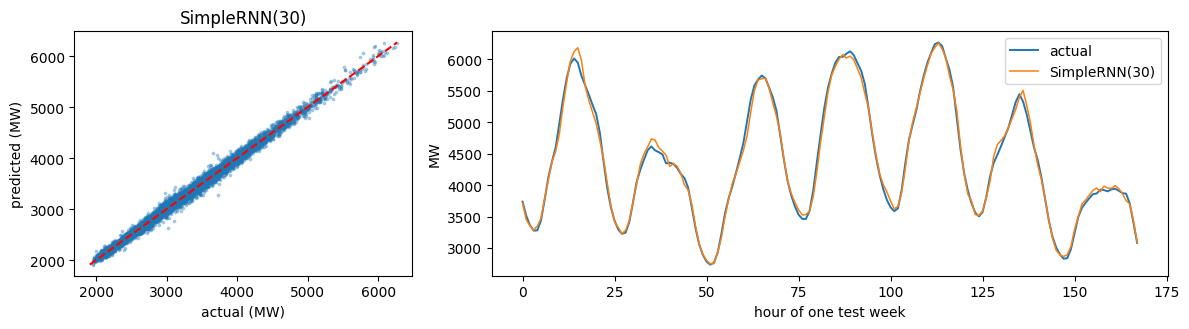

In [9]:
i0 = 24*7*28
plt.figure(figsize=(11, 3)); plt.plot(y_true[i0:i0+24*7], label="actual"); plt.plot(pred_rnn[i0:i0+24*7], label="SimpleRNN (1h ahead)")
plt.title("One test week"); plt.ylabel("MW"); plt.legend(); plt.show()
show_results("SimpleRNN(30)", pred_rnn)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10B — Multivariate RNN Pt 2: the LSTM swap, stacking, and a classification head
- One-word swap: SimpleRNN -> LSTM. Params x4: (8+30)*30+30 = 1,170 -> 4,680. Read it off summary().
- Stacked: return_sequences=True keeps the (24, 30) sequence for the second layer. More capacity is not automatically better - read the table.
- Bake-off table: persistence 129, seasonal naive 227, SimpleRNN ~48, LSTM ~43, stacked ~67 (worse - more capacity is not automatically better). The number to say: how much value over the naive baseline.
- Close on the scoreboard: every model against persistence and seasonal naive, and the gap that actually matters. so read precision/recall.
- Save -> load_model -> identical predictions. Reproducibility is a seed AND a saved artifact.
-->


## The LSTM swap, and a stacked RNN

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,711 (18.40 KB)

 Trainable params: 4,711 (18.40 KB)

 Non-trainable params: 0 (0.00 B)

Restoring model weights from the end of the best epoch: 50.


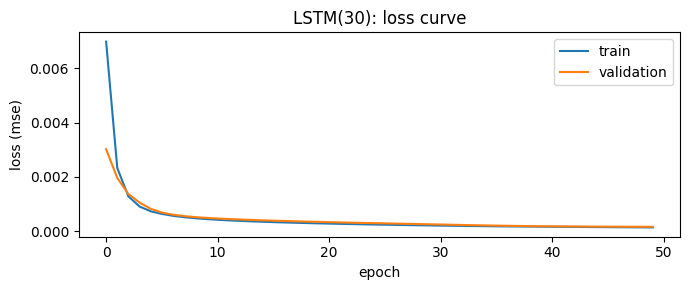

stopped after 50 epochs; best validation loss 0.00016
LSTM(30): test MAE = 43.2 MW   (persistence 129.0, seasonal naive 227.1)


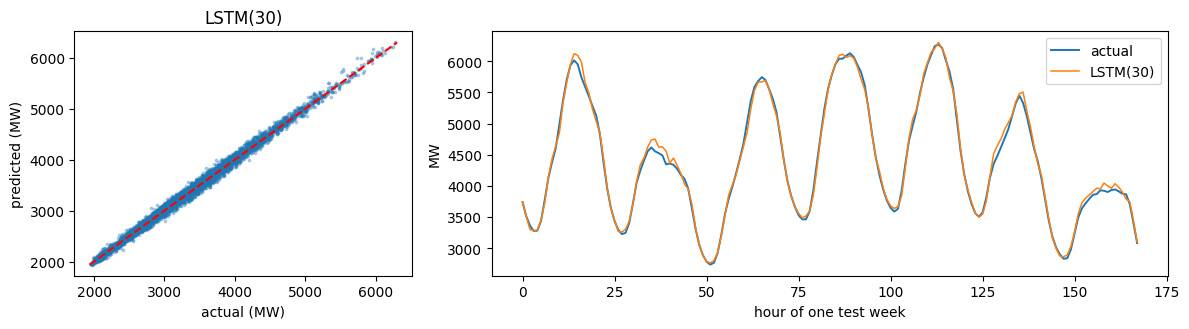

In [10]:
lstm = Sequential()
lstm.add(Input(shape=(n_steps, n_features)))
lstm.add(LSTM(30))
lstm.add(Dense(1))
lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm.summary()
hist_lstm = lstm.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_lstm = sc_y.inverse_transform(lstm.predict(X_test, verbose=0)).ravel()

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_lstm.history["loss"], label="train")
if "val_loss" in hist_lstm.history:
    plt.plot(hist_lstm.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("LSTM(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_lstm.history['loss'])} epochs;"
      f" best validation loss {min(hist_lstm.history['val_loss']):.5f}")
show_results("LSTM(30)", pred_lstm)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 24, 30)         │         1,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,031 (11.84 KB)

 Trainable params: 3,031 (11.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 19.


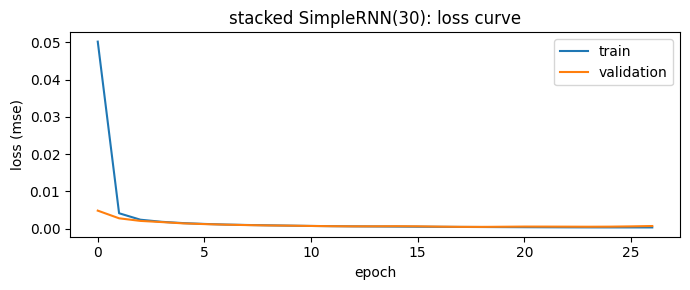

stopped after 27 epochs; best validation loss 0.00044
stacked SimpleRNN(30): test MAE = 67.1 MW   (persistence 129.0, seasonal naive 227.1)


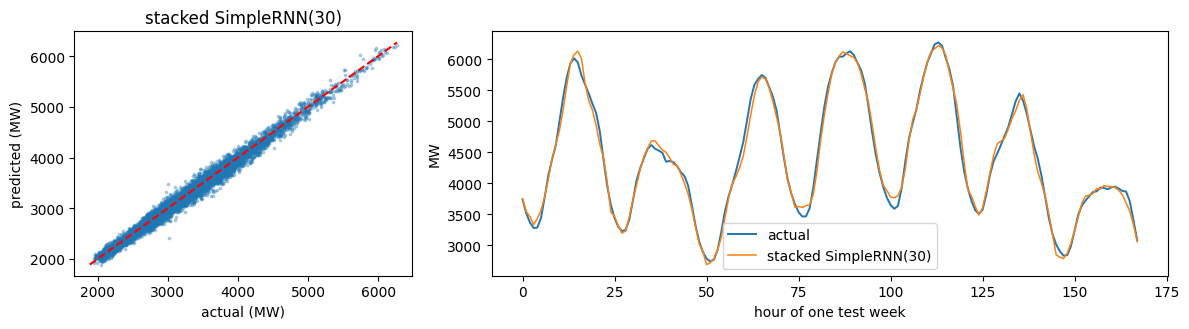

In [11]:
stacked = Sequential()
stacked.add(Input(shape=(n_steps, n_features)))
stacked.add(SimpleRNN(30, return_sequences=True))    # hands the whole (24, 30) sequence down
stacked.add(SimpleRNN(30))
stacked.add(Dense(1))
stacked.compile(optimizer="adam", loss="mse", metrics=["mae"])
stacked.summary()
hist_stacked = stacked.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
pred_stacked = sc_y.inverse_transform(stacked.predict(X_test, verbose=0)).ravel()

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(hist_stacked.history["loss"], label="train")
if "val_loss" in hist_stacked.history:
    plt.plot(hist_stacked.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("stacked SimpleRNN(30): loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist_stacked.history['loss'])} epochs;"
      f" best validation loss {min(hist_stacked.history['val_loss']):.5f}")
show_results("stacked SimpleRNN(30)", pred_stacked)

## The scoreboard

Every model next to the baselines it had to beat. The number that matters is not the MAE itself - it is the gap
between a model and **seasonal naive**, because "same hour yesterday" is free and already very good on a load
series.

In [12]:
board = pd.concat([baselines, pd.Series(scores, name="test MAE (MW)")]).sort_values()
display(board.to_frame())
best, naive = board.index[0], baselines["seasonal naive (same hour yday)"]
print(f"best: {best} at {board.iloc[0]:.1f} MW")
print(f"seasonal naive: {naive:.1f} MW  ->  the best model is {100*(naive-board.iloc[0])/naive:+.0f}% on that baseline")

,test MAE (MW)
LSTM(30),43.2
SimpleRNN(30),47.9
stacked SimpleRNN(30),67.1
persistence (last hour),129.0
seasonal naive (same hour yday),227.1
mean-only,563.3


best: LSTM(30) at 43.2 MW
seasonal naive: 227.1 MW  ->  the best model is +81% on that baseline


## Save the model and use it again

In [13]:
lstm.save('E2_Multivariate_Demand_RNN.keras')
reloaded = load_model('E2_Multivariate_Demand_RNN.keras')
print("reloaded model reproduces the predictions:", np.allclose(lstm.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Change `n_steps` to 6, then 168. Which look-back wins for one hour ahead? For the peak-hour flag?
- Add `Dropout(0.2)` after the recurrent layer. Does it help a model that is already close to persistence?
- Swap `LSTM` for `GRU` - count the parameters before you run it (G=3).